# CMPS 460 – Machine Learning
## Assignment 1: Data Preprocessing & Exploratory Data Analysis

**Dataset:** Individual Household Electric Power Consumption  
**Source:** UCI Machine Learning Repository  
**Dataset Link:** https://archive.ics.uci.edu/ml/datasets/individual+household+electric+power+consumption

**Student Name:**  
**Student ID:**  

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Part A – Dataset Understanding & Motivation

## Dataset Description
The Individual Household Electric Power Consumption dataset contains minute-level electrical measurements collected from a single household between December 2006 and November 2010.
It includes:
*   Global active power
*   Global reactive power
*   Voltage
*   Global intensity
Sub-metering values (kitchen, laundry, water heater)

The dataset contains over 2 million records and 9+ attributes, making it large and realistic.

## Domain
Energy analytics and smart grid systems.

## Why Interesting?
- Helps analyze household energy behavior
- Useful for energy forecasting
- Supports smart energy optimization

## Potential ML Applications
- Predict power consumption
- Detect abnormal energy usage
- Time-series forecasting

Load Dataset

In [2]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


Part B – Data Preprocessing & Cleaning

**1.1 Data Inspection**

In [3]:
df.shape

(782844, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782844 entries, 0 to 782843
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   782844 non-null  object 
 1   Time                   782843 non-null  object 
 2   Global_active_power    782843 non-null  object 
 3   Global_reactive_power  782843 non-null  object 
 4   Voltage                782843 non-null  object 
 5   Global_intensity       782843 non-null  object 
 6   Sub_metering_1         782843 non-null  object 
 7   Sub_metering_2         782843 non-null  object 
 8   Sub_metering_3         778901 non-null  float64
dtypes: float64(1), object(8)
memory usage: 53.8+ MB


In [5]:
df.describe()

,Sub_metering_3
count,778901.000000
mean,6.062240
std,8.286621
min,0.000000
25%,0.000000
50%,0.000000
75%,17.000000
max,31.000000


Observations:

*   Dataset contains ~2 million rows.
*   Several numeric columns are stored as object type.
*   Missing values are represented using '?'.
*   Date and Time are stored separately.
Identified Data Quality Issues:
*   Missing values represented as strings
*   Incorrect data types
*   Potential duplicate rows
*   Extreme values in consumption
























1.2 Handling Missing Values

In [6]:
df.replace('?', np.nan, inplace=True)
df.isnull().sum()

,0
Date,0
Time,1
Global_active_power,3943
Global_reactive_power,3943
Voltage,3943
Global_intensity,3943
Sub_metering_1,3943
Sub_metering_2,3943
Sub_metering_3,3943


In [7]:
cols = df.columns[2:]
df[cols] = df[cols].astype(float)

In [8]:
df.fillna(df.median(numeric_only=True), inplace=True)



```
# Justification:

Energy consumption data may contain extreme spikes.

Mean is sensitive to outliers.

Median is more robust, making it a better choice.

Removing rows would reduce valuable time-series continuity.
```



1.3 Data Cleaning

In [9]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                 format='%d/%m/%Y %H:%M:%S')

In [10]:
df.drop(columns=['Date','Time'], inplace=True)

In [11]:
df.drop_duplicates(inplace=True)

1.4 Outlier Detection

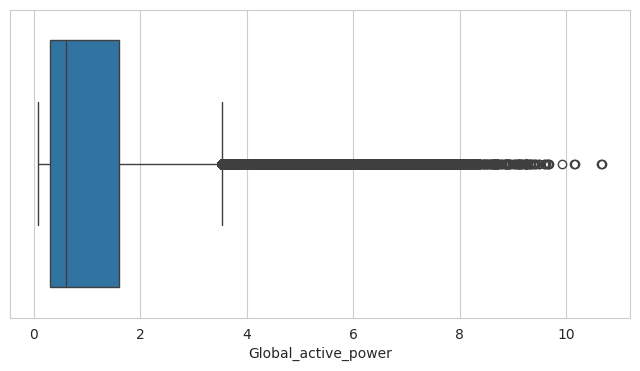

In [12]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Global_active_power'])
plt.show()

In [13]:
Q1 = df['Global_active_power'].quantile(0.25)
Q3 = df['Global_active_power'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Global_active_power'] < Q1 - 1.5*IQR) |
              (df['Global_active_power'] > Q3 + 1.5*IQR)]

len(outliers)

41584



```
# Outliers were retained because extreme energy usage may represent
real high-consumption periods rather than errors.
```

[link text](https://)

# **1.5 Feature Engineering**

Extract time-based features

In [14]:
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Hour'] = df['Datetime'].dt.hour
df['DayOfWeek'] = df['Datetime'].dt.day_name()

Encode categorical feature

In [15]:
df = pd.get_dummies(df, columns=['DayOfWeek'], drop_first=True)

**Part C – Exploratory Data Analysis**

**2.1 Univariate Analysis**

Global Active Power

Statistics

In [16]:
df['Global_active_power'].mean()
df['Global_active_power'].median()
df['Global_active_power'].std()

1.1602499579774745

Histogram

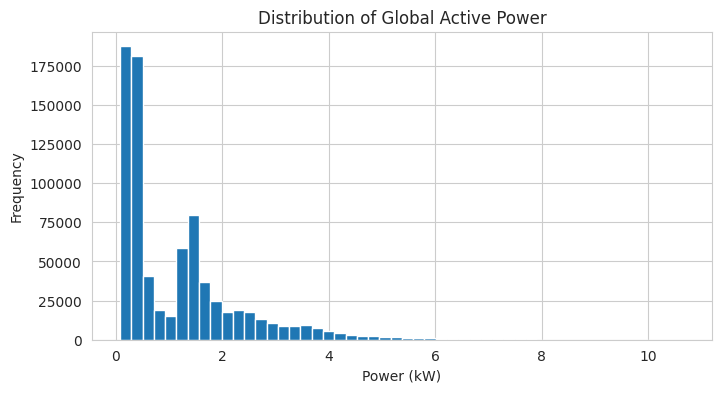

In [17]:
plt.figure(figsize=(8,4))
plt.hist(df['Global_active_power'], bins=50)
plt.title("Distribution of Global Active Power")
plt.xlabel("Power (kW)")
plt.ylabel("Frequency")
plt.show()

Boxplot

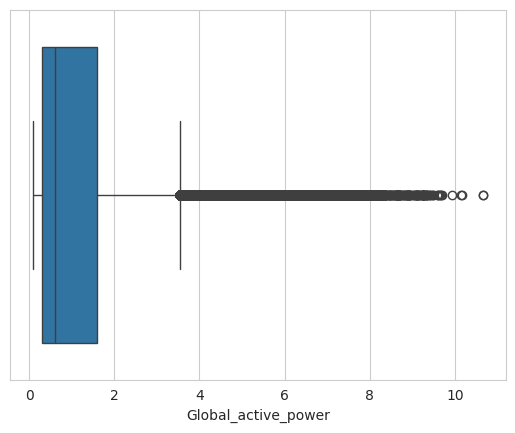

In [18]:
sns.boxplot(x=df['Global_active_power'])
plt.show()



```
# The distribution is right-skewed, indicating most consumption values
are low, with occasional high usage peaks.
```



**2.2 Bivariate Analysis & Multivariate Analysis**

Question 1: Is Global Intensity correlated with Global Active Power?



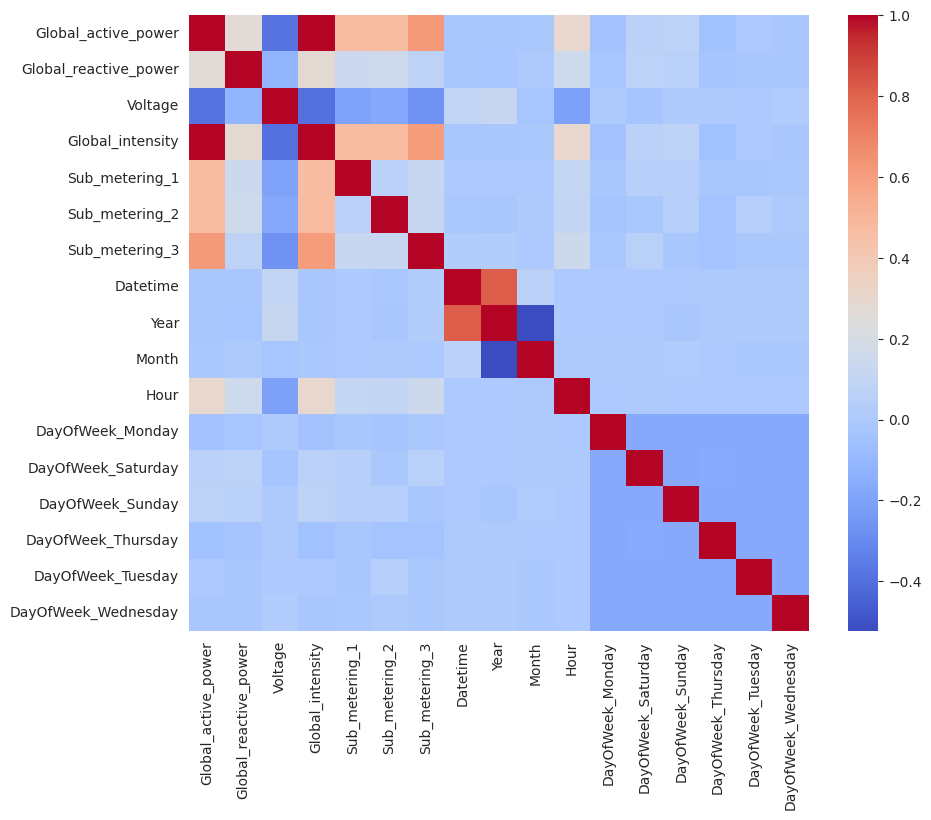

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

Interpretation:
*   Strong positive correlation exists.
*   As intensity increases, active power increases.
*   Physically consistent with electrical relationship.

Question 2: Does Voltage influence Power Consumption?

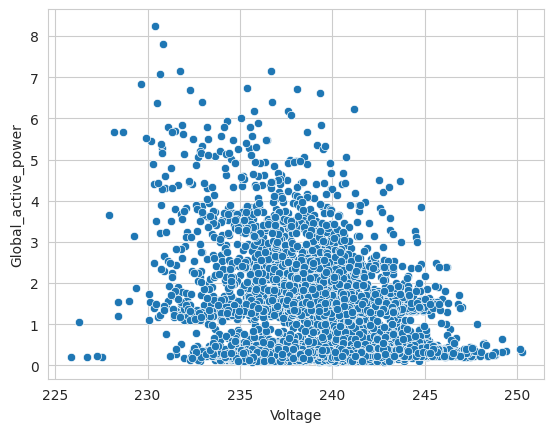

In [20]:
sns.scatterplot(x='Voltage',
                y='Global_active_power',
                data=df.sample(5000))
plt.show()

Insight:
*   Weak relationship observed.
*   Voltage remains relatively stable.



Question 3: How does power vary by hour?

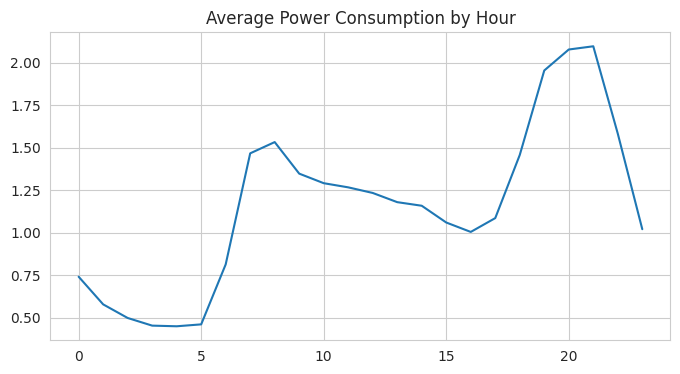

In [21]:
hourly = df.groupby('Hour')['Global_active_power'].mean()

plt.figure(figsize=(8,4))
plt.plot(hourly)
plt.title("Average Power Consumption by Hour")
plt.show()

Insight:
Higher consumption during:
*   Evening hours
*   After working hours
Indicates behavioral usage patterns.

Question 4: Multivariate Relationships

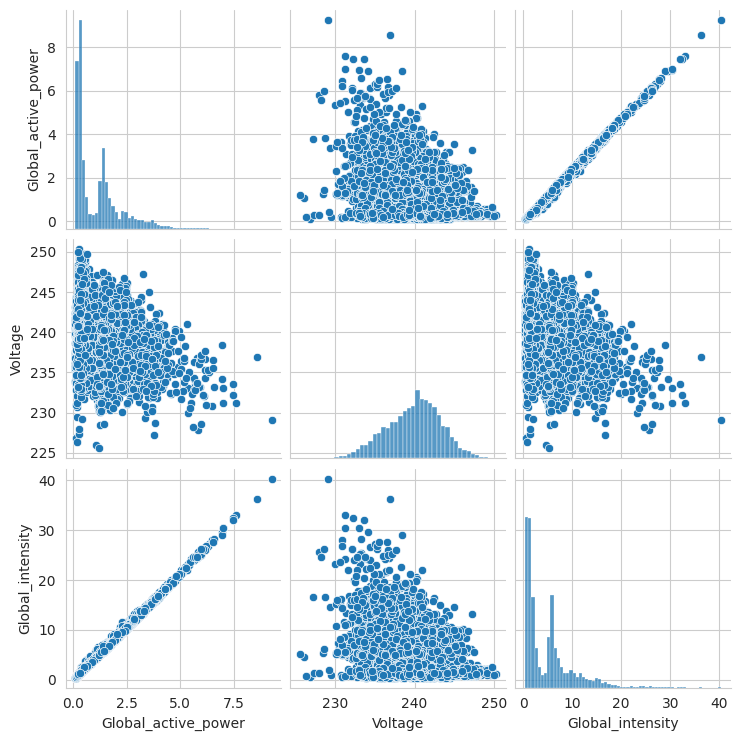

In [22]:
sns.pairplot(df[['Global_active_power',
                 'Voltage',
                 'Global_intensity']].sample(5000))
plt.show()

Insight:


*   Strong linear relationship between intensity & power
*   Weak relationship between voltage & others







**Final Conclusion**



```
#  Conclusion

Data Quality Issues Found:
- Missing values represented as '?'
- Incorrect data types
- Extreme values in power consumption

Preprocessing Steps:
- Replaced missing values
- Converted numeric columns
- Feature engineering for time variables
- Removed duplicates

Key Insights:
- Energy usage is higher during evening hours.
- Strong positive correlation exists between Global Active Power
  and Global Intensity.
- Data shows right-skewed consumption behavior.

The dataset is now cleaned and suitable for predictive modeling,
such as time-series forecasting of energy consumption.
```

